In [2]:
import pandas as pd

hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet")
hour_df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [ ]:
import boto3
import matplotlib.pyplot as plt
from pathlib import Path

bucket_name = "dsan6000-lj589"
prefix = "wikipedia-hourly/"

s3 = boto3.client("s3")

In [4]:
response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix=prefix
)

parquet_keys = [
    obj["Key"]
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".parquet")
]

len(parquet_keys)

24

In [5]:
parquet_keys

['wikipedia-hourly/20260901_040000.parquet',
 'wikipedia-hourly/20260901_050000.parquet',
 'wikipedia-hourly/20260901_060000.parquet',
 'wikipedia-hourly/20260901_070000.parquet',
 'wikipedia-hourly/20260901_080000.parquet',
 'wikipedia-hourly/20260901_090000.parquet',
 'wikipedia-hourly/20260901_100000.parquet',
 'wikipedia-hourly/20260901_110000.parquet',
 'wikipedia-hourly/20260901_120000.parquet',
 'wikipedia-hourly/20260901_130000.parquet',
 'wikipedia-hourly/20260901_140000.parquet',
 'wikipedia-hourly/20260901_150000.parquet',
 'wikipedia-hourly/20260901_160000.parquet',
 'wikipedia-hourly/20260901_170000.parquet',
 'wikipedia-hourly/20260901_180000.parquet',
 'wikipedia-hourly/20260901_190000.parquet',
 'wikipedia-hourly/20260901_200000.parquet',
 'wikipedia-hourly/20260901_210000.parquet',
 'wikipedia-hourly/20260901_220000.parquet',
 'wikipedia-hourly/20260901_230000.parquet',
 'wikipedia-hourly/20260902_000000.parquet',
 'wikipedia-hourly/20260902_010000.parquet',
 'wikipedi

In [6]:
hourly_dfs = []

for key in parquet_keys:
    s3_uri = f"s3://{bucket_name}/{key}"
    hour_df = pd.read_parquet(s3_uri)
    hourly_dfs.append(hour_df)

df = pd.concat(hourly_dfs, ignore_index=True)

In [7]:
df.shape

(119708, 29)

In [8]:
df.columns

Index(['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title',
       'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url',
       'minor', 'length', 'revision', 'server_url', 'server_name',
       'server_script_path', 'wiki', 'parsedcomment', 'log_id', 'log_type',
       'log_action', 'log_params', 'log_action_comment', 'patrolled',
       'file_ts', 'file_ts_str'],
      dtype='str')

In [9]:
df.head

<bound method NDFrame.head of                    datetime                        $schema  \
0       2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
1       2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
2       2026-09-01 04:00:01  /mediawiki/recentchange/1.0.0   
3       2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
4       2026-09-01 04:00:03  /mediawiki/recentchange/1.0.0   
...                     ...                            ...   
119703  2026-09-02 03:44:51  /mediawiki/recentchange/1.0.0   
119704  2026-09-02 03:44:53  /mediawiki/recentchange/1.0.0   
119705  2026-09-02 03:44:53  /mediawiki/recentchange/1.0.0   
119706  2026-09-02 03:44:54  /mediawiki/recentchange/1.0.0   
119707  2026-09-02 03:44:51  /mediawiki/recentchange/1.0.0   

                                                     meta            id  type  \
0       {'uri': 'https://en.wikipedia.org/wiki/Jake_O%...  2.063884e+09  edit   
1       {'uri': 'https://en.wikipedia.org/wiki/Beverid...  2.06

In [10]:
df[["datetime", "type"]].head()

,datetime,type
0,2026-09-01 04:00:02,edit
1,2026-09-01 04:00:02,edit
2,2026-09-01 04:00:01,edit
3,2026-09-01 04:00:02,edit
4,2026-09-01 04:00:03,edit


In [11]:
df["type"].value_counts()

type
edit    110896
new       4411
log       4401
Name: count, dtype: int64

In [12]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [13]:
df["hour"] = df["datetime"].dt.floor("h")

In [14]:
hourly_counts = (
    df.groupby("hour")
      .size()
      .reset_index(name="event_count")
)

hourly_counts

,hour,event_count
0,2026-09-01 04:00:00,4458
1,2026-09-01 05:00:00,3769
2,2026-09-01 06:00:00,3981
3,2026-09-01 07:00:00,3186
4,2026-09-01 08:00:00,3519
5,2026-09-01 09:00:00,3316
6,2026-09-01 10:00:00,3654
7,2026-09-01 11:00:00,4056
8,2026-09-01 12:00:00,4599
9,2026-09-01 13:00:00,6200


In [15]:
hourly_type_counts = (
    df.groupby(["hour", "type"])
      .size()
      .reset_index(name="event_count")
)

hourly_type_counts.head()

,hour,type,event_count
0,2026-09-01 04:00:00,edit,3959
1,2026-09-01 04:00:00,log,440
2,2026-09-01 04:00:00,new,59
3,2026-09-01 05:00:00,edit,3429
4,2026-09-01 05:00:00,log,199


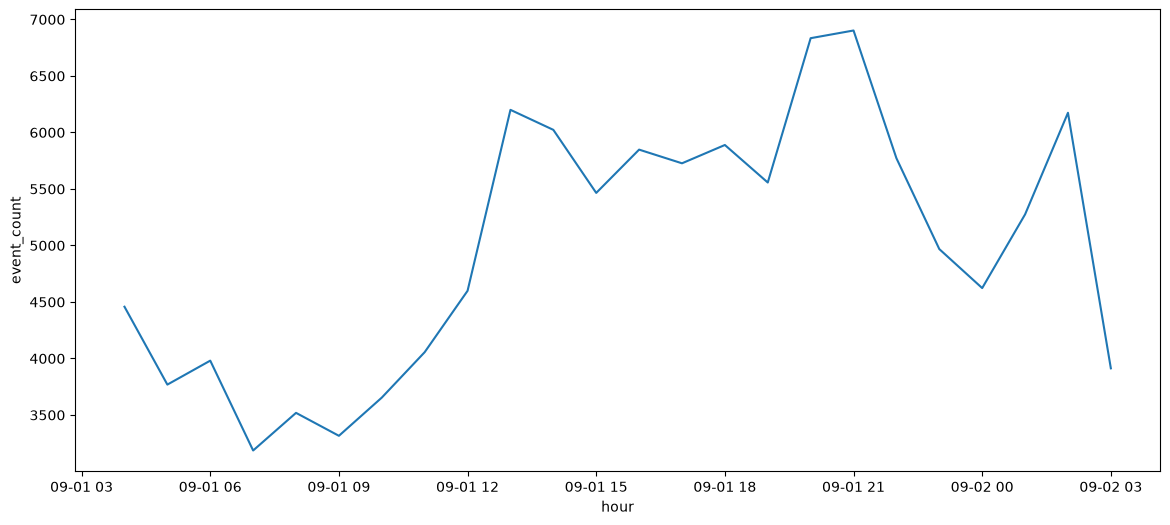

In [21]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=hourly_counts,
    x="hour",
    y="event_count"
)

plt.savefig("images/hourly-events.png")
plt.savefig("images/hourly-events.svg")

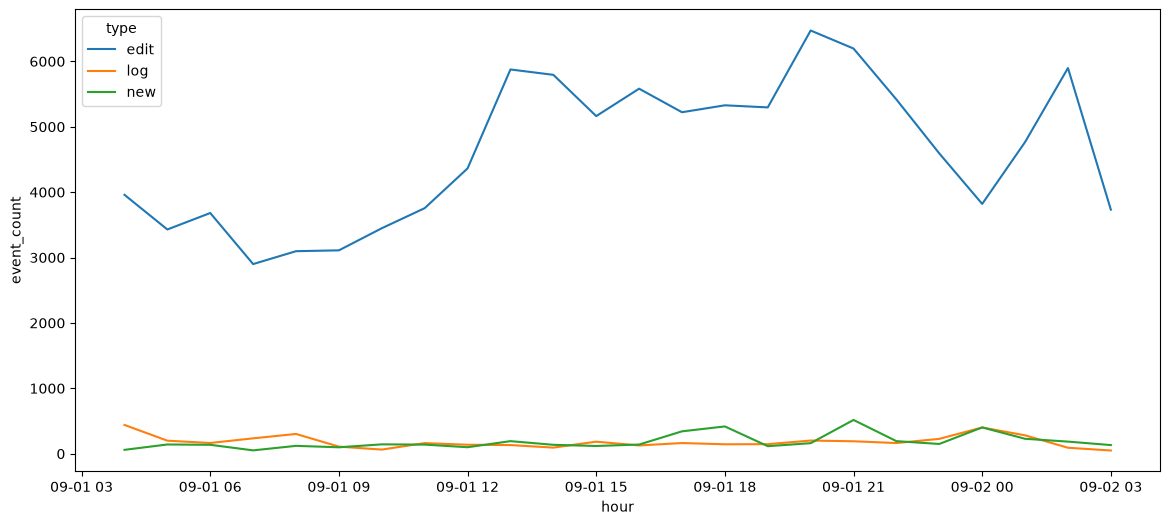

In [22]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=hourly_type_counts,
    x="hour",
    y="event_count",
    hue="type"
)
plt.savefig("images/events-by-type.png")
plt.savefig("images/events-by-type.svg")